In [1]:
import numpy as np
import matplotlib.pyplot as plt

import constants
import vertical_profile as vp
import heterostructure_models.dot_2d as d2
import solvers
from matplotlib.colors import Normalize


No alloy disorder

Norm v0: 1.0
Norm v1: 1.0


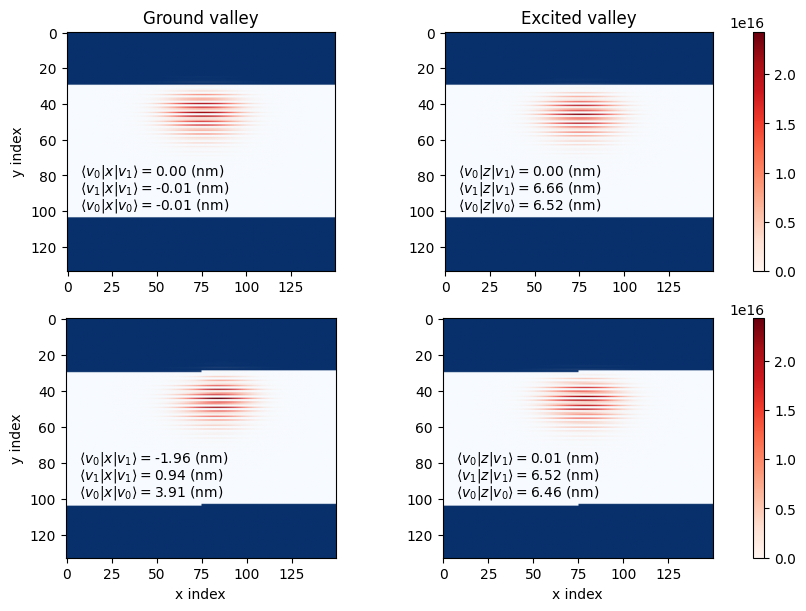

In [2]:
# Sharp vertical profile, so we see the impact of a step on the valley splitting
prof = vp.VerticalProfile(interface_type='sharp', top_cap_width_nm=4, bot_cap_width_nm=4)

#####################
# No step simulations
#####################

d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='none', disorder_model='none', nx=150)
lat_nostep = d2d.effective_lattice

model_tb = solvers.TwoBand_2D(
    effective_lattice = lat_nostep, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d2d.dx_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_2D_matrix_from_vector(v0)
v1 = model_tb.wf_2D_matrix_from_vector(v1)

# Test normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model_tb.dz * model_tb.dx)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model_tb.dz * model_tb.dx)}")

# Probability density
density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

# Used for plotting
alphas_0 = Normalize(clip=True)(density_0)
alphas_1 = Normalize(clip=True)(density_1)

# Dipolar matrix elements
x01 = model_tb.x01_nm
x00 = model_tb.x00_nm
x11 = model_tb.x11_nm

z01 = model_tb.z01_nm
z00 = model_tb.z00_nm
z11 = model_tb.z11_nm

#####################
# Step simulations
#####################
step_ind = 75
d2dstep = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='single-step', disorder_model='none', step_position_index=step_ind, nx=150)
lat_step = d2dstep.effective_lattice


model_tb_step = solvers.TwoBand_2D(
    effective_lattice = lat_step, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d2dstep.dx_nm
)

evals, evecs = model_tb_step.solve(n_lowest_eigenstates=2)
v0_step = evecs[:,0]
v1_step = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0_step = model_tb_step.wf_2D_matrix_from_vector(v0_step)
v1_step = model_tb_step.wf_2D_matrix_from_vector(v1_step)

# Probability density
density_0_step = np.abs(v0_step)**2
density_1_step = np.abs(v1_step)**2

# Used for plotting
alphas_0_step = Normalize(clip=True)(density_0_step)
alphas_1_step = Normalize(clip=True)(density_1_step)

# Dipolar matrix elements
x01_step = model_tb_step.x01_nm
x00_step = model_tb_step.x00_nm
x11_step = model_tb_step.x11_nm

z01_step = model_tb_step.z01_nm
z00_step = model_tb_step.z00_nm
z11_step = model_tb_step.z11_nm

# Plotting
fig, ax = plt.subplots(2, 2, figsize=(8,6), layout='constrained')

max_wf = max([np.max(v0**2), np.max(v1**2), np.max(v0_step**2), np.max(v1_step**2)])
max_pot = max([np.max(lat_step), np.max(lat_nostep)])

ax[0,0].imshow(1-lat_nostep.T, cmap='Blues', vmin=0, vmax=0.3)
im0 = ax[0,0].imshow(density_0.T, alpha=alphas_0.T, cmap="Reds",  vmin=0, vmax=max_wf)
ax[0,0].set_title('Ground valley')

ax[0,1].imshow(1-lat_nostep.T, cmap='Blues', vmin=0, vmax=0.3)
im1 = ax[0,1].imshow(density_1.T, alpha=alphas_1.T, cmap="Reds",  vmin=0, vmax=max_wf)
fig.colorbar(im1, ax=ax[0,1])
ax[0,1].set_title(f'Single Step at index {step_ind}')
ax[0,1].set_title('Excited valley')

ax[0,0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0,0].transAxes)
ax[0,0].text(0.05, 0.33, r"$\langle v_1 | x | v_1 \rangle = $" + f"{x11:0.2f} (nm)", transform=ax[0,0].transAxes)
ax[0,0].text(0.05, 0.4, r"$\langle v_0 | x | v_1 \rangle = $" + f"{x01:0.2f} (nm)", transform=ax[0,0].transAxes)

ax[0,1].text(0.05, 0.26, r"$\langle v_0 | z | v_0 \rangle = $" + f"{z00:0.2f} (nm)", transform=ax[0,1].transAxes)
ax[0,1].text(0.05, 0.33, r"$\langle v_1 | z | v_1 \rangle = $" + f"{z11:0.2f} (nm)", transform=ax[0,1].transAxes)
ax[0,1].text(0.05, 0.4, r"$\langle v_0 | z | v_1 \rangle = $" + f"{z01:0.2f} (nm)", transform=ax[0,1].transAxes)


ax[1,0].imshow(1-lat_step.T, cmap='Blues', vmin=0, vmax=0.3)
im0 = ax[1,0].imshow(density_0_step.T, alpha=alphas_0_step.T, cmap="Reds",  vmin=0, vmax=max_wf)

ax[1,1].imshow(1-lat_step.T, cmap='Blues', vmin=0, vmax=0.3)
im0 = ax[1,1].imshow(density_1_step.T, alpha=alphas_1_step.T, cmap="Reds",  vmin=0, vmax=max_wf)
fig.colorbar(im0, ax=ax[1,1])

ax[1,0].text(0.05, 0.26, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00_step:0.2f} (nm)", transform=ax[1,0].transAxes)
ax[1,0].text(0.05, 0.33, r"$\langle v_1 | x | v_1 \rangle = $" + f"{x11_step:0.2f} (nm)", transform=ax[1,0].transAxes)
ax[1,0].text(0.05, 0.4, r"$\langle v_0 | x | v_1 \rangle = $" + f"{x01_step:0.2f} (nm)", transform=ax[1,0].transAxes)

ax[1,1].text(0.05, 0.26, r"$\langle v_0 | z | v_0 \rangle = $" + f"{z00_step:0.2f} (nm)", transform=ax[1,1].transAxes)
ax[1,1].text(0.05, 0.33, r"$\langle v_1 | z | v_1 \rangle = $" + f"{z11_step:0.2f} (nm)", transform=ax[1,1].transAxes)
ax[1,1].text(0.05, 0.4, r"$\langle v_0 | z | v_1 \rangle = $" + f"{z01_step:0.2f} (nm)", transform=ax[1,1].transAxes)


ax[1,0].set_xlabel('x index')
ax[1,1].set_xlabel('x index')
ax[0,0].set_ylabel('y index')
ax[1,0].set_ylabel('y index')

plt.show()



Including alloy disorder

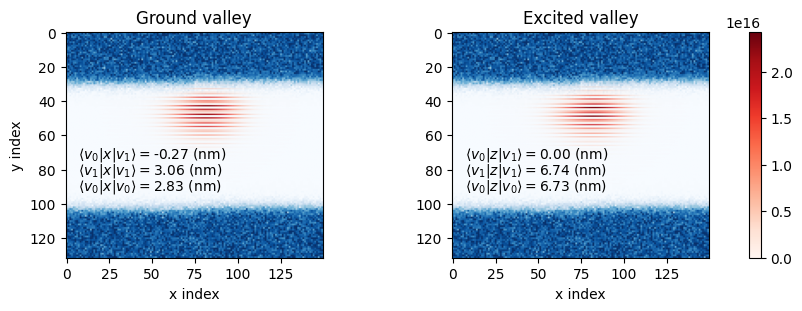

In [3]:
prof = vp.VerticalProfile(interface_type='sigmoid', top_cap_width_nm=4, bot_cap_width_nm=4)

# No step simulations
d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='single-step', disorder_model='alloy', nx=150, y_orbital_spacing=2e-3, step_position_index=75)
lat = d2d.effective_lattice

model_tb = solvers.TwoBand_2D(
    effective_lattice = lat, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d2d.dx_nm
)

evals, evecs = model_tb.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model_tb.wf_2D_matrix_from_vector(v0)
v1 = model_tb.wf_2D_matrix_from_vector(v1)

density_0 = np.abs(v0)**2
density_1 = np.abs(v1)**2

alphas_0 = Normalize(clip=True)(density_0)
alphas_1 = Normalize(clip=True)(density_1)

# Dipolar matrix elements
x01 = model_tb.x01_nm
x00 = model_tb.x00_nm
x11 = model_tb.x11_nm

z01 = model_tb.z01_nm
z00 = model_tb.z00_nm
z11 = model_tb.z11_nm

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(8,3), layout='constrained')

max_wf = max([np.max(v0**2), np.max(v1**2), np.max(v0_step**2), np.max(v1_step**2)])
max_pot = max([np.max(lat_step), np.max(lat_nostep)])

ax[0].imshow(1-lat.T, cmap='Blues', vmin=0, vmax=0.35)
im0 = ax[0].imshow(density_0.T, alpha=alphas_0.T, cmap="Reds",  vmin=0, vmax=max_wf)
ax[0].set_title('Ground valley')

ax[1].imshow(1-lat.T, cmap='Blues', vmin=0, vmax=0.35)
im1 = ax[1].imshow(density_1.T, alpha=alphas_1.T, cmap="Reds",  vmin=0, vmax=max_wf)
fig.colorbar(im1, ax=ax[1])
ax[1].set_title(f'Single Step at index {step_ind}')
ax[1].set_title('Excited valley')

ax[0].text(0.05, 0.3, r"$\langle v_0 | x | v_0 \rangle = $" + f"{x00:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.37, r"$\langle v_1 | x | v_1 \rangle = $" + f"{x11:0.2f} (nm)", transform=ax[0].transAxes)
ax[0].text(0.05, 0.44, r"$\langle v_0 | x | v_1 \rangle = $" + f"{x01:0.2f} (nm)", transform=ax[0].transAxes)

ax[1].text(0.05, 0.3, r"$\langle v_0 | z | v_0 \rangle = $" + f"{z00:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.37, r"$\langle v_1 | z | v_1 \rangle = $" + f"{z11:0.2f} (nm)", transform=ax[1].transAxes)
ax[1].text(0.05, 0.44, r"$\langle v_0 | z | v_1 \rangle = $" + f"{z01:0.2f} (nm)", transform=ax[1].transAxes)


ax[0].set_xlabel('x index')
ax[1].set_xlabel('x index')
ax[0].set_ylabel('y index')

plt.show()

2D effective mass simulations

Valley splitting = 2.390182539317952e-09


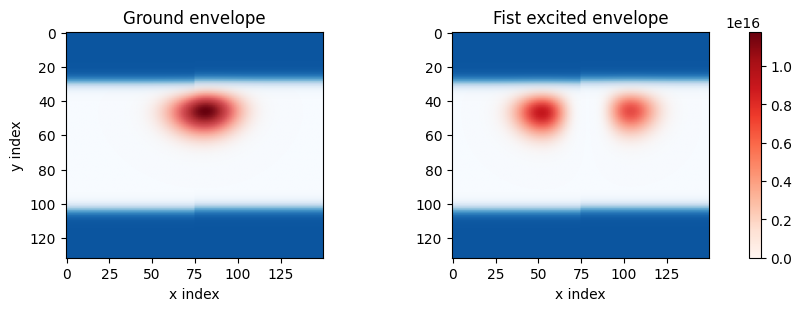

In [4]:
prof = vp.VerticalProfile(interface_type='sigmoid', top_cap_width_nm=4, bot_cap_width_nm=4)

# No step simulations
d2d = d2.Dot2D(si_concentrations=prof.si_concentrations, step_model='single-step', disorder_model='none', nx=150, y_orbital_spacing=2e-3, step_position_index=75)
lat = d2d.effective_lattice

model = solvers.EffectiveMass_2D(
    effective_lattice = lat, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.005,
    dx_nm = d2d.dx_nm
)

evals, evecs = model.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]


# Print the valley splitting
ev = model.valley_splitting
print(f"Valley splitting = {ev}")

# Convert vectors v0 and v1 to 2D matrices for viewing
v0 = model.wf_2D_matrix_from_vector(v0)
v1 = model.wf_2D_matrix_from_vector(v1)

density_0 = np.abs(v0)**2
alphas_0 = Normalize(clip=True)(density_0)

density_1 = np.abs(v1)**2
alphas_1 = Normalize(clip=True)(density_1)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(8,3), layout='constrained')

max_wf = max([np.max(v0**2), np.max(v1**2)])
max_pot = np.max(lat)

ax[0].imshow(1-lat.T, cmap='Blues', vmin=0, vmax=0.35)
im0 = ax[0].imshow(density_0.T, alpha=alphas_0.T, cmap="Reds",  vmin=0, vmax=max_wf)
ax[0].set_title('Ground envelope')

ax[1].imshow(1-lat.T, cmap='Blues', vmin=0, vmax=0.35)
im1 = ax[1].imshow(density_1.T, alpha=alphas_1.T, cmap="Reds",  vmin=0, vmax=max_wf)
fig.colorbar(im1, ax=ax[1])
ax[1].set_title('Fist excited envelope')

ax[0].set_xlabel('x index')
ax[1].set_xlabel('x index')
ax[0].set_ylabel('y index')

plt.show()